In [1]:
"""
graph.py
전·월세 분쟁 팩트체커 — LangGraph 상태 그래프
 
구조:
  parent: START → (entry_router) → pre_contract | post_contract → 공통 응답 파이프라인 → END
  pre subgraph : 문서 여부 라우팅 → OCR·서류분석·전세가율·위험판정 | 계약 질의 분석 → 컨텍스트
  post subgraph: 쟁점 분류 → 컨텍스트
  공통 파이프라인: retrieve → grade(→쿼리 재작성 루프) → generate → verify(→재생성 루프) → 법적 고지
 
검색은 vs_method.search_similar(pgvector) 사용.
  ⚠️ 검색 결과는 {**metadata, content, similarity} 형태이며 metadata 키는 문서마다 다르다.
     (법령: law_name/article, 판례: court/case_no …) → 모든 접근은 .get() 으로 방어.
멀티턴은 그래프 내부 루프가 아니라 MemorySaver + thread_id 로 상태를 유지하고 매 턴 재호출한다.
 
설치:
  pip install langgraph langchain-openai "psycopg[binary]" pgvector
환경변수:
  OPENAI_API_KEY, DB_URL (vs_method 가 사용)
"""
 
from __future__ import annotations
 
import json
from typing import Optional
 
from typing_extensions import TypedDict, Annotated
 
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage
 
from dotenv import load_dotenv
load_dotenv()
 
import vs_method  # search_similar / get_conn
 
# ──────────────────────────────────────────────
# LLM / 검색 연결
# ──────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0, timeout=30, max_retries=2)
 
MAX_RETRIEVAL_ATTEMPTS = 2
MAX_VERIFY_ATTEMPTS = 2
 
_conn = None
def conn():
    global _conn
    if _conn is None:
        _conn = vs_method.get_conn()
    return _conn
 
 
def _llm_json(prompt: str) -> dict:
    """LLM 응답을 JSON 으로 강제 파싱. 실패 시 빈 dict."""
    raw = llm.invoke(prompt + "\n\nJSON 객체만 출력. 설명·마크다운 금지.").content
    raw = raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}
 
 
def _history_text(state: "FactCheckState", n: int = 6) -> str:
    """최근 대화 n개를 프롬프트용 텍스트로. 법적 고지 꼬리는 제거해 노이즈 감소."""
    lines = []
    for m in (state.get("messages") or [])[-n:]:
        role = "사용자" if isinstance(m, HumanMessage) else "상담봇"
        content = (getattr(m, "content", "") or "").split("\n\n---\n")[0]
        lines.append(f"{role}: {content[:200]}")
    return "\n".join(lines) or "(이전 대화 없음)"


def _doc_context(state: "FactCheckState") -> str:
    """OCR/서류 분석(findings)을 답변·검증 프롬프트용 텍스트로. 없으면 빈 문자열."""
    f = state.get("findings") or {}

    def won(v):
        try:
            return f"{int(v):,}원"
        except Exception:
            return str(v)

    lines = []
    if f.get("special_terms"):
        lines.append("특약: " + " / ".join(str(x) for x in f["special_terms"]))
    if f.get("flags"):
        lines.append("주의 특약·요소: " + " / ".join(str(x) for x in f["flags"]))
    if f.get("deposit"):
        lines.append("보증금(추출): " + won(f["deposit"]))
    if f.get("senior_debt"):
        lines.append("선순위 채권(추출): " + won(f["senior_debt"]))
    if not lines and state.get("document_text"):
        lines.append(state["document_text"][:800])   # 구조화 실패 시 원문 일부
    return "\n".join(lines)
 
 
def _cite(h: dict) -> str:
    """source_type 별 출처 표기 (metadata 키가 문서마다 다르므로 .get 으로 분기)."""
    st = h.get("source_type")
    if st in ("statute", "interpretation"):
        return " ".join(x for x in (h.get("law_name"), h.get("article")) if x) or h.get("doc_title", "")
    if st == "precedent":
        return " ".join(x for x in (h.get("court"), h.get("case_no")) if x) or h.get("doc_title", "")
    if st in ("mediation_case", "counsel_case"):
        no = h.get("case_no") or h.get("사례번호")
        return f"{h.get('doc_title','')} {no}".strip() if no else h.get("doc_title", "")
    return h.get("doc_title", "")  # standard_contract / guide 등
 
 
# ──────────────────────────────────────────────
# 공유 State
# ──────────────────────────────────────────────
class FactCheckState(TypedDict, total=False):
    # 입력 / 세션
    stage: str                       # 'pre' | 'post'
    question: str
    intent: str                      # 'chitchat' | 'legal'
    has_document: bool
    document_path: Optional[str]        # 단일 파일 (하위호환)
    document_paths: Optional[list]      # 여러 파일 경로 리스트
    market_price: Optional[int]       # 매매 시세(원) — 유저 입력 (전세가율 계산용)
    messages: Annotated[list, add_messages]
    # 계약 전 산출물
    document_text: Optional[str]
    findings: Optional[dict]          # 근저당·선순위·보증금 등
    risk_result: Optional[dict]       # {level, ratio, reasons}
    # 검색 / 생성 공통
    query: str
    issues: list
    retrieved: list
    retrieval_attempts: int
    answer: str
    verify_attempts: int
 
 
# ══════════════════════════════════════════════
# 외부 파이프라인 스텁 (기존 모듈에 연결)
# ══════════════════════════════════════════════
def run_ocr(document_path: str) -> str:
    """업로드 서류(PDF/이미지)에서 텍스트 추출.
    src/adapter/ocr_get_text.extract_document 에 연결 (지연 import).
    - graph.py = src/core/graph.py 기준으로 src/adapter 를 경로에 추가
    - ocr_get_text 는 import 시 OpenAI()/fitz/PIL 을 요구하므로 여기서만 로드
    - 모델은 OCR_MODEL 환경변수로 교체 가능 (기본 gpt-4o)
    """
    import os as _os
    import sys as _sys
    from importlib import import_module
 
    adapter_dir = _os.path.join(
        _os.path.dirname(_os.path.dirname(_os.path.abspath(__file__))), "adapter"
    )
    if adapter_dir not in _sys.path:
        _sys.path.insert(0, adapter_dir)
 
    ocr = import_module("ocr_get_text")
    result = ocr.extract_document(document_path, model=_os.getenv("OCR_MODEL", "gpt-4o"))
    text = (result or {}).get("text", "").strip()
    if not text:
        raise RuntimeError("OCR 결과가 비어 있습니다 (스캔 품질·해상도를 확인하세요).")
    return text
 
 
# 매매 시세는 API 대신 유저 입력으로 받는다 → state["market_price"] (원)
 
 
# ══════════════════════════════════════════════
# 계약 전 서브그래프
# ══════════════════════════════════════════════
def pre_entry_router(state: FactCheckState) -> str:
    return "doc" if state.get("has_document") else "question"
 
 
def ocr_extract(state: FactCheckState) -> dict:
    """업로드된 파일(여러 개 가능)을 각각 OCR해 파일명 라벨과 함께 하나로 합친다."""
    import os as _os
    paths = state.get("document_paths") or (
        [state["document_path"]] if state.get("document_path") else []
    )
    parts = []
    for p in paths:
        try:
            txt = run_ocr(p)
        except Exception as e:                      # 한 파일 실패해도 나머지는 진행
            txt = f"[읽기 실패: {e}]"
        parts.append(f"===== 파일: {_os.path.basename(p)} =====\n{txt}")
    return {"document_text": "\n\n".join(parts)}
 
 
def analyze_document(state: FactCheckState) -> dict:
    """등기부·계약서 텍스트에서 근저당·선순위·보증금·특약 추출 (LLM)."""
    data = _llm_json(
        "다음 등기부/계약서에서 위험 요소를 추출해라.\n"
        'keys: deposit(보증금·정수), senior_debt(선순위 채권액·정수), '
        'address(문자열), special_terms(특약 리스트), flags(위험 특약 리스트).\n\n'
        f"{state['document_text'][:8000]}"
    )
    return {"findings": data}
 
 
def calc_jeonse_ratio(state: FactCheckState) -> dict:
    """결정론적 계산: (보증금 + 선순위채권) / 매매시세.  시세는 유저 입력(state['market_price']).
    시세·보증금이 없으면 전세가율은 None 으로 두고 위험 판정에서 '정보 부족' 처리."""
    f = state.get("findings") or {}
    deposit = int(f.get("deposit") or 0)
    senior = int(f.get("senior_debt") or 0)
    price = int(state.get("market_price") or 0)     # 유저 입력 시세(원)
    if price <= 0 or deposit <= 0:
        return {"findings": {**f, "jeonse_ratio": None, "market_price": price or None}}
    ratio = round((deposit + senior) / price, 3)
    return {"findings": {**f, "jeonse_ratio": ratio, "market_price": price}}
 
 
def assess_risk(state: FactCheckState) -> dict:
    """결정론적 임계값 판정. 전세가율이 없으면(시세/보증금 미입력) '정보 부족'."""
    f = state.get("findings") or {}
    ratio = f.get("jeonse_ratio")
    reasons, level = [], "low"
    if ratio is None:
        level = "unknown"
        reasons.append("매매 시세 또는 보증금 미입력 → 전세가율 계산 생략")
    elif ratio >= 0.8:
        level = "high"
        reasons.append(f"전세가율 {ratio:.0%} (깡통전세 위험 구간)")
    elif ratio >= 0.7:
        level = "medium"
        reasons.append(f"전세가율 {ratio:.0%} (경계 구간)")
    if f.get("senior_debt"):
        reasons.append("선순위 근저당 존재 → 우선변제 순위 확인 필요")
    return {"risk_result": {"level": level, "ratio": ratio, "reasons": reasons}}
 
 
def analyze_pre_query(state: FactCheckState) -> dict:
    """대화 맥락을 반영해 마지막 질문을 검색용 '독립형 쿼리'로 변환 + 쟁점 태그 (LLM)."""
    data = _llm_json(
        "아래 대화 맥락을 반영해, 사용자의 '마지막 질문'(계약 전)을 그 자체로 검색 가능한 "
        "독립형 쿼리로 만들어라. 지시대명사(그거·그때·거기 등)는 맥락으로 풀어 완전한 문장으로.\n"
        'keys: query(자립형 검색 문장), issues(태그 리스트: '
        'deposit,opposing_power,priority_repayment,fraud,special_terms 중).\n\n'
        f"[최근 대화]\n{_history_text(state)}\n\n마지막 질문: {state.get('question','')}"
    )
    return {"query": data.get("query", state.get("question", "")),
            "issues": data.get("issues", [])}
 
 
def build_pre_context(state: FactCheckState) -> dict:
    """위험 판정 결과가 있으면 검색 쿼리·쟁점에 병합. stage 고정."""
    out = {"stage": "pre", "retrieval_attempts": 0, "verify_attempts": 0}
    risk = state.get("risk_result")
    if risk and risk["reasons"]:
        out["query"] = state.get("query", "") + " / " + "; ".join(risk["reasons"])
        out["issues"] = list({*state.get("issues", []), "fraud", "priority_repayment"})
    return out
 
 
def build_pre_graph():
    g = StateGraph(FactCheckState)
    g.add_node("ocr_extract", ocr_extract)
    g.add_node("analyze_document", analyze_document)
    g.add_node("calc_jeonse_ratio", calc_jeonse_ratio)
    g.add_node("assess_risk", assess_risk)
    g.add_node("analyze_pre_query", analyze_pre_query)
    g.add_node("build_pre_context", build_pre_context)
 
    g.add_conditional_edges(START, pre_entry_router,
                            {"doc": "ocr_extract", "question": "analyze_pre_query"})
    g.add_edge("ocr_extract", "analyze_document")
    g.add_edge("analyze_document", "calc_jeonse_ratio")
    g.add_edge("calc_jeonse_ratio", "assess_risk")
    g.add_edge("assess_risk", "analyze_pre_query")   # 문서 경로도 질의 분석으로 합류
    g.add_edge("analyze_pre_query", "build_pre_context")
    g.add_edge("build_pre_context", END)
    return g.compile()
 
 
# ══════════════════════════════════════════════
# 공통 응답 파이프라인
# ══════════════════════════════════════════════
# 검색 필터 사용 여부.
#   False → stage/issue 필터 없이 순수 벡터 유사도로만 검색.
#           (적재본 태그 어휘가 파이프라인 enum 과 안 맞아 0건 나오던 문제 회피)
#   True  → 기존처럼 stage/issue 필터 적용. 단 search_similar 에 폴백 사다리가 있어
#           0건이면 자동 완화됨. 태그 스키마를 정규화해 재적재한 뒤 다시 켜면 됨.
USE_FILTERS = False


def retrieve(state: FactCheckState) -> dict:
    """pgvector 검색. binding·persuasive 함께 가져와 뒤에서 층 분리.
    USE_FILTERS=False 면 stage/issue 필터 없이 벡터 유사도만 사용."""
    if USE_FILTERS:
        hits = vs_method.search_similar(
            conn(),
            query=state["query"],
            stage=state.get("stage"),
            issues=state.get("issues") or None,
            k=8,
            min_score=0.15,
        )
    else:
        hits = vs_method.search_similar(
            conn(),
            query=state["query"],
            k=8,
            min_score=0.15,
        )
    return {"retrieved": hits}
 
 
def grade_documents(state: FactCheckState) -> dict:
    """검색 결과가 질문을 커버하는지 판정 (관련성 평가)."""
    ctx = "\n".join(
        f"- ({h.get('authority','?')}) {h.get('content','')[:120]}"
        for h in state["retrieved"]
    )
    v = _llm_json(
        "검색된 조항이 질문에 답하기에 충분한가?\n"
        'keys: sufficient(bool), gap(부족하면 무엇이 빠졌는지 한 문장).\n\n'
        f"질문: {state['query']}\n조항:\n{ctx or '(없음)'}"
    )
    return {"_grade": v}  # 임시 채널 (라우터에서 읽고 버림)
 
 
def grade_router(state: FactCheckState) -> str:
    v = state.get("_grade", {})
    if v.get("sufficient"):
        return "generate"
    if state.get("retrieval_attempts", 0) < MAX_RETRIEVAL_ATTEMPTS:
        return "rewrite"
    return "generate"  # 상한 초과 → 있는 근거로 진행(부족 고지)
 
 
def rewrite_query(state: FactCheckState) -> dict:
    """부족한 부분을 반영해 쿼리 재작성 후 재검색 루프."""
    gap = state.get("_grade", {}).get("gap", "")
    new_q = llm.invoke(
        f"원 질문: {state['query']}\n부족한 점: {gap}\n"
        "검색이 잘 되도록 쿼리를 한 문장으로 재작성해라. 문장만 출력."
    ).content.strip()
    return {"query": new_q, "retrieval_attempts": state.get("retrieval_attempts", 0) + 1}
 
 
def generate(state: FactCheckState) -> dict:
    """근거 기반 답변 생성. 결론은 binding, 사례는 persuasive 로 층 분리."""
    retrieved = state["retrieved"]
    binding = [h for h in retrieved if h.get("authority") == "binding"]
    persuasive = [h for h in retrieved if h.get("authority") == "persuasive"]
    ref = [h for h in retrieved if h.get("authority") == "reference"]
 
    def fmt(hs):
        # source_type 별 출처 표기(_cite): 법령→법령명·조항, 판례→법원·사건번호, 사례→문서명
        return "\n".join(
            f"- {_cite(h)}: {h.get('content','')[:200]}" for h in hs
        ) or "(없음)"
 
    risk = state.get("risk_result")
    risk_txt = f"\n[위험 진단] {risk['level']} / {'; '.join(risk['reasons'])}" if risk else ""

    dc = _doc_context(state)                       # OCR/서류 분석 결과
    doc_txt = f"[업로드 서류 분석]\n{dc}\n\n" if dc else ""
 
    answer = llm.invoke(
        "너는 세입자를 돕는 법률 정보 도우미다. 아래 근거만 사용해 답하라.\n"
        "규칙: 결론의 법적 근거는 반드시 [법령·판례]에서 인용하고 출처"
        "(법령명·조항 또는 법원·사건번호)를 명시하라. "
        "[사례]는 '이런 경우 이렇게 판단된 적 있다'는 참고로만. 근거에 없는 내용은 단정하지 말 것. "
        "[업로드 서류 분석]이 있으면 그 특약·위험요소를 근거 법령과 연결해 사용자 상황에 맞춰 구체적으로 답하라. "
        "이전 대화 맥락을 고려해 자연스럽게 이어서 답하라.\n"
        f"{risk_txt}\n\n"
        f"[대화 맥락]\n{_history_text(state)}\n\n"
        f"{doc_txt}"
        f"[법령·판례]\n{fmt(binding)}\n\n[사례]\n{fmt(persuasive)}\n\n[실무 참고]\n{fmt(ref)}\n\n"
        f"질문: {state.get('question','')}"
    ).content.strip()
    return {"answer": answer}
 
 
def verify(state: FactCheckState) -> dict:
    """답변이 검색 근거+업로드 서류에 충실한지(환각 여부) 검증."""
    ctx = "\n".join(f"- {h.get('content','')[:200]}" for h in state["retrieved"])
    dc = _doc_context(state)
    if dc:
        ctx += "\n[업로드 서류]\n" + dc
    v = _llm_json(
        "답변이 아래 근거에 충실한가? 근거(검색 조항 + 업로드 서류)에 없는 사실 단정이 있으면 faithful=false.\n"
        'keys: faithful(bool), problem(문제 있으면 한 문장).\n\n'
        f"근거:\n{ctx}\n\n답변:\n{state['answer']}"
    )
    return {"_verify": v}
 
 
def verify_router(state: FactCheckState) -> str:
    v = state.get("_verify", {})
    if v.get("faithful"):
        return "end"
    if state.get("verify_attempts", 0) < MAX_VERIFY_ATTEMPTS:
        return "regenerate"
    return "end"  # 상한 초과 → 고지에 한계 명시
 
 
def bump_verify(state: FactCheckState) -> dict:
    return {"verify_attempts": state.get("verify_attempts", 0) + 1}
 
 
DISCLAIMER = ("\n\n---\n※ 본 답변은 법률 정보 제공이며 변호사의 법률 자문이 아닙니다. "
              "구체적 사안은 대한법률구조공단(132) 또는 변호사 상담을 권장합니다.")
 
 
# def legal_notice(state: FactCheckState) -> dict:
#     """법적 고지 부착 후 최종 답변 확정 + 세션 기록."""
#     final = state["answer"] + DISCLAIMER
#     return {"answer": final, "messages": [AIMessage(content=final)]}
 
 
# ══════════════════════════════════════════════
# 부모 그래프
# ══════════════════════════════════════════════
def classify_intent(state: FactCheckState) -> dict:
    """법률 질문 vs 일상대화(인사·감사·잡담) 분류. 모호하면 legal(안전)."""
    v = _llm_json(
        "사용자 메시지의 의도를 분류하라.\n"
        "chitchat: 인사·감사·잡담·자기소개·서비스 사용법 등 법률과 무관한 대화.\n"
        "legal: 전월세 계약·보증금·수리·분쟁·전세사기 등 법률 정보가 필요한 질문.\n"
        'keys: intent("chitchat"|"legal").\n\n'
        f"[최근 대화]\n{_history_text(state)}\n\n메시지: {state.get('question','')}"
    )
    return {"intent": v.get("intent", "legal")}
 
 
def intake_router(state: FactCheckState) -> str:
    if state.get("intent") == "chitchat":
        return "chitchat"
    return "pre_contract"
 
 
def chitchat(state: FactCheckState) -> dict:
    """검색·법적 고지 없이 짧고 친근하게 응답. 서비스로 자연스럽게 유도."""
    answer = llm.invoke(
        "너는 전·월세 세입자를 돕는 친근한 상담봇이다. 아래는 일상 대화다. "
        "짧고 따뜻하게 한국어로 답하고, 필요하면 '계약 전 위험 진단'이나 '계약 후 분쟁 상담'을 "
        "도울 수 있다고 자연스럽게 덧붙여라. 법률 조언·근거 인용·법적 고지는 하지 마라.\n\n"
        f"[최근 대화]\n{_history_text(state)}\n\n사용자: {state.get('question','')}"
    ).content.strip()
    return {"answer": answer, "messages": [AIMessage(content=answer)]}
 
 
def build_app():
    g = StateGraph(FactCheckState)
 
    # 진입: 의도 분류 → 일상대화 / 법률(계약 전·후)
    g.add_node("intake", classify_intent)
    g.add_node("chitchat", chitchat)
 
    # 서브그래프를 노드로 장착 (State 공유)
    g.add_node("pre_contract", build_pre_graph())
 
    # 공통 파이프라인
    g.add_node("retrieve", retrieve)
    g.add_node("grade", grade_documents)
    g.add_node("rewrite_query", rewrite_query)
    g.add_node("generate", generate)
    g.add_node("verify", verify)
    g.add_node("bump_verify", bump_verify)
    # g.add_node("legal_notice", legal_notice)
 
    # 진입 라우팅: 잡담이면 chitchat 로 바로 종료, 아니면 stage 별 서브그래프
    g.add_edge(START, "intake")
    g.add_conditional_edges("intake", intake_router, {
        "chitchat": "chitchat",
        "pre_contract": "pre_contract"
    })
    g.add_edge("chitchat", END)
    g.add_edge("pre_contract", "retrieve")
 
    # 검색 → 관련성 평가 (→ 쿼리 재작성 루프)
    g.add_edge("retrieve", "grade")
    g.add_conditional_edges("grade", grade_router,
                            {"generate": "generate", "rewrite": "rewrite_query"})
    g.add_edge("rewrite_query", "retrieve")
 
    # 생성 → 충실성 검증 (→ 재생성 루프)
    g.add_edge("generate", "verify")
    g.add_conditional_edges("verify", verify_router,
                            {"end": END, "regenerate": "bump_verify"})
    g.add_edge("bump_verify", "generate")
    #g.add_edge("legal_notice", END)
 
    return g.compile(checkpointer=MemorySaver())
 
 
app = build_app()
 
 
# ──────────────────────────────────────────────
# 한 턴 실행 헬퍼 (멀티턴 = 같은 thread_id 로 재호출)
# ──────────────────────────────────────────────
def run_turn(thread_id: str, question: str, *, stage: str,
             has_document: bool = False, document_path: str | None = None,
             document_paths: list | None = None,
             market_price: int | None = None) -> str:
    cfg = {"configurable": {"thread_id": thread_id}}
    out = app.invoke(
        {"question": question, "stage": stage,
         "has_document": has_document,
         "document_path": document_path, "document_paths": document_paths,
         "market_price": market_price,
         "messages": [HumanMessage(content=question)]},   # 사용자 발화를 히스토리에 적재
        config=cfg,
    )
    return out["answer"]
 


# ══════════════════════════════════════════════
# 🛠️ 실시간 터미널 대화용 실행 블록 // Test용
# ══════════════════════════════════════════════
if __name__ == "__main__":
    import uuid
    
    # 1. 세션 구분을 위한 고유 thread_id 발급
    thread_id = str(uuid.uuid4())[:8]
    print(f"\n==================================================")
    print(f"🏠 전·월세 분쟁 팩트체커 실행 (세션 ID: {thread_id})")
    print(f"==================================================")
    print("※ 종료하려면 '종료' 또는 'exit'를 입력하세요.\n")
    
    # 2. 계약 단계 최초 1회 선택
    while True:
        stage_input = input("현재 어떤 단계의 질의인가요?\n(1: 계약 전/안전성 진단, 2: 계약 후/분쟁 발생) ➡️ 번호 입력: ").strip()
        if stage_input in ["1", "2"]:
            stage = "pre" if stage_input == "1" else "post"
            break
        print("❌ 잘못된 입력입니다. 1 또는 2를 입력해 주세요.\n")
        
    print(f"\n➡️ [{'계약 전' if stage=='pre' else '계약 후'}] 모드로 실시간 대화를 시작합니다.")
    
    # 3. 사용자 입력 대화 루프 시작
    while True:
        question = input("\n👤 임차인 질문 입력: ").strip()
        
        # 종료 조건
        if question.lower() in ["종료", "exit", "quit"]:
            print("\n👋 팩트체커 프로그램을 종료합니다. 안전한 거래 되세요!")
            break
            
        if not question:
            print("⚠️ 질문을 입력해 주세요.")
            continue
            
        print("\n🔍 관련 법령 및 판례 검색 중... 잠시만 기다려주세요...")
        
        try:
            # 상태 그래프 재호출 (동일한 thread_id로 이전 문맥 유지 가능)
            answer = run_turn(thread_id=thread_id, question=question, stage=stage)
            print(f"\n🤖 [팩트체커 답변]:\n{answer}")
            print(f"\n" + "─"*50)
        except Exception as e:
            print(f"\n❌ 에러가 발생했습니다: {e}")


🏠 전·월세 분쟁 팩트체커 실행 (세션 ID: d8f4a3af)
※ 종료하려면 '종료' 또는 'exit'를 입력하세요.


➡️ [계약 후] 모드로 실시간 대화를 시작합니다.

👋 팩트체커 프로그램을 종료합니다. 안전한 거래 되세요!


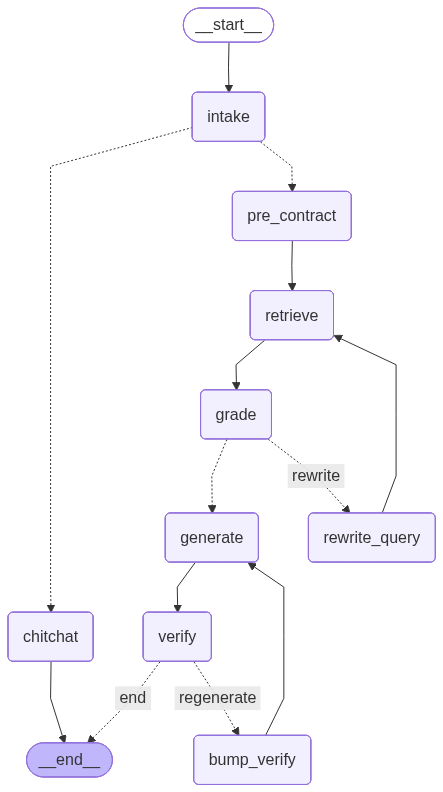

In [2]:
app

In [5]:
pre_contract

NameError: name 'pre_contract' is not defined